# Model 3 - GAP + BatchNorm CNN

Takes the GAP model and adds `BatchNormalization` after every conv
(Conv -> BN -> ReLU) - the single change. BatchNorm normalizes layer inputs, so
it usually converges faster and regularizes a little further. Tracked on
**validation** metrics like every other variant.

## 1. Setup & imports

Shared pipeline modules; imports the BatchNorm model factory.

In [1]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "preprocessing", "label_mapping"))
sys.path.append(os.path.join(os.getcwd(), "preprocessing", "data_loader"))
sys.path.append(os.path.join(os.getcwd(), "model"))
sys.path.append(os.path.join(os.getcwd(), "evaluation", "model_metrics"))
sys.path.append(os.path.join(os.getcwd(), "evaluation", "plots"))

import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

from label_mapping import build_labeled_dataset
from data_loader import build_train_val_test_generators
from gap_bn_cnn import build_gap_bn_cnn
from model_metrics import debug_model, evaluate_model, record_result
from plots import plot_misclassified

## 2. Load & label the dataset

Build the image index (Italian folder -> English label, root-relative paths).

In [2]:
df = build_labeled_dataset()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26179 entries, 0 to 26178
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  26179 non-null  object
 1   label_it    26179 non-null  object
 2   label_en    26179 non-null  object
dtypes: object(3)
memory usage: 613.7+ KB


## 3. Preprocess: split, resize, normalize

Identical preprocessing to models 1-2 (128x128, rescale 1/255, stratified
70/15/15) so the only variable is BatchNorm.

In [3]:
train_generator, val_generator, test_generator = build_train_val_test_generators(
    df, project_root=os.getcwd(), image_size=(128, 128)
)
train_generator.class_indices

Found 18325 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.
Found 3927 validated image filenames belonging to 10 classes.


{'butterfly': 0,
 'cat': 1,
 'chicken': 2,
 'cow': 3,
 'dog': 4,
 'elephant': 5,
 'horse': 6,
 'sheep': 7,
 'spider': 8,
 'squirrel': 9}

## 4. Build the CNN

The GAP model with **BatchNormalization** added after every conv
(`Conv -> BN -> ReLU`) - the single change vs model 2.

In [4]:
model = build_gap_bn_cnn(
    input_shape=train_generator.image_shape,
    num_classes=len(train_generator.class_indices),
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 124, 124, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 58, 58, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 58, 58, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 27, 27, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 290,090 (1.11 MB)

 Trainable params: 289,194 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

## 5. Train — or load a saved model

If `models_saved/gap_bn_cnn.keras` already exists it's **loaded** (skips the
~60-min retrain); otherwise it trains and is saved. BatchNorm makes `val_loss`
volatile early, so `patience=6`. Set `RETRAIN = True` to force a fresh run.

In [5]:
import time
from tensorflow import keras

# Load the saved model if present so a kernel restart doesn't cost a full
# retrain. Delete the file or set RETRAIN=True to train fresh.
MODEL_PATH = "models_saved/gap_bn_cnn.keras"
RETRAIN = False

if not RETRAIN and os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    history, train_time_min = None, None
    print(f"Loaded {MODEL_PATH} (skipped training).")
else:
    early_stopping = EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True
    )
    start_time = time.time()
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=30,
        callbacks=[early_stopping],
    )
    train_time_min = round((time.time() - start_time) / 60, 1)
    print(f"Trained in {train_time_min} min.")

Loaded models_saved/gap_bn_cnn.keras (skipped training).


## 6. Training history

Compare `acc_gap` and convergence speed vs GAP-without-BN (model 2). BN should
reach good accuracy in fewer epochs.

In [6]:
# Training history — only when we actually trained this run.
if history is not None:
    history_df = pd.DataFrame(history.history)
    history_df.index.name = "epoch"
    history_df["acc_gap"] = history_df["accuracy"] - history_df["val_accuracy"]
    display(history_df)
else:
    print("Model was loaded from disk — no training history this run.")

Model was loaded from disk — no training history this run.


## 7. Evaluate: per-class report + confusion matrix

Score on the validation set; per-class precision/recall/F1 + confusion-matrix
heatmap.

123/123 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step
              precision    recall  f1-score   support

   butterfly       0.94      0.70      0.80       317
         cat       0.89      0.25      0.39       250
     chicken       0.77      0.79      0.78       464
         cow       0.56      0.69      0.62       280
         dog       0.63      0.74      0.68       730
    elephant       0.82      0.66      0.73       217
       horse       0.49      0.83      0.61       393
       sheep       0.74      0.61      0.67       273
      spider       0.79      0.84      0.81       723
    squirrel       0.91      0.35      0.50       280

    accuracy                           0.69      3927
   macro avg       0.75      0.64      0.66      3927
weighted avg       0.74      0.69      0.69      3927



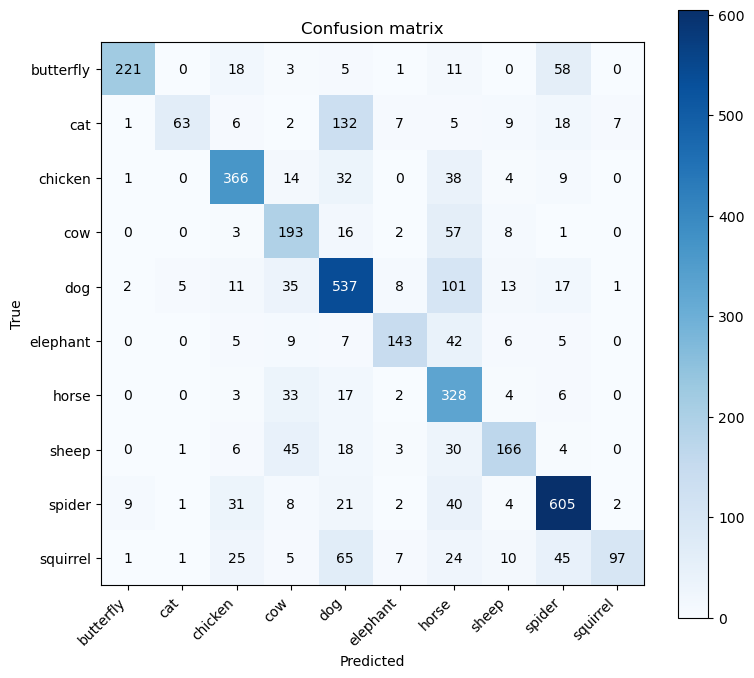

,butterfly,cat,chicken,cow,dog,elephant,horse,sheep,spider,squirrel
butterfly,221,0,18,3,5,1,11,0,58,0
cat,1,63,6,2,132,7,5,9,18,7
chicken,1,0,366,14,32,0,38,4,9,0
cow,0,0,3,193,16,2,57,8,1,0
dog,2,5,11,35,537,8,101,13,17,1
elephant,0,0,5,9,7,143,42,6,5,0
horse,0,0,3,33,17,2,328,4,6,0
sheep,0,1,6,45,18,3,30,166,4,0
spider,9,1,31,8,21,2,40,4,605,2
squirrel,1,1,25,5,65,7,24,10,45,97


In [7]:
debug_model(model, val_generator)

## 8. Misclassified images

Grid of validation images the model got wrong (true -> pred).

123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step


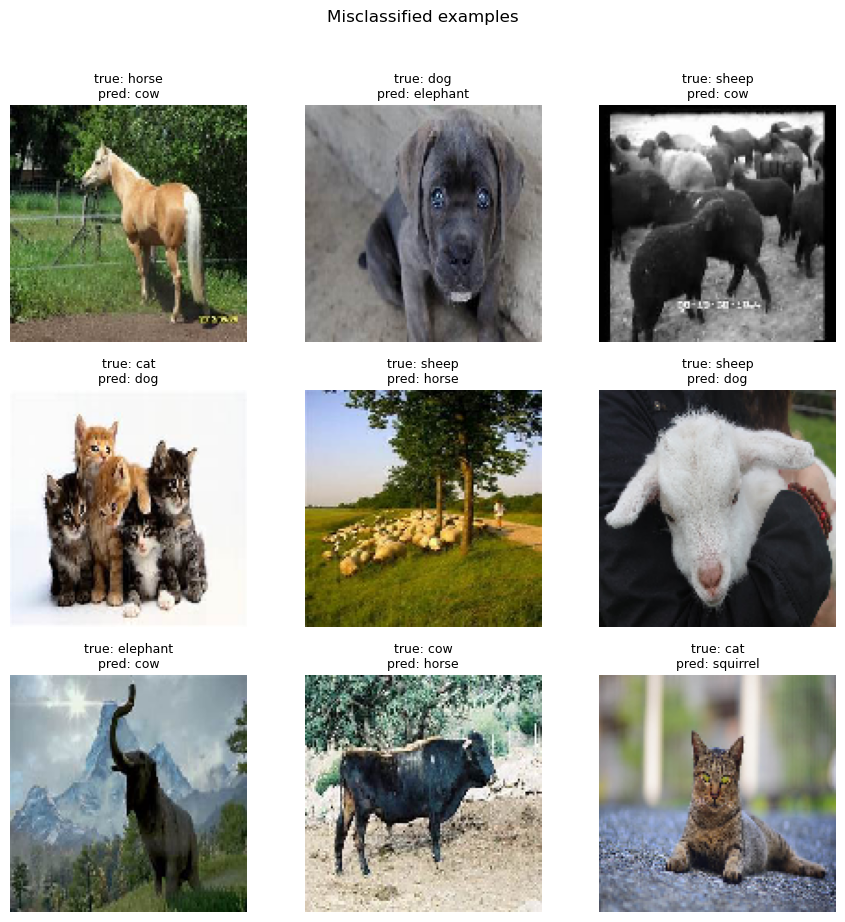

In [8]:
plot_misclassified(model, val_generator)

## 9. Record result to the tracking sheet

Upsert this model's validation row into `model_tracking.csv` (LR and train time
measured from the run).

In [9]:
learning_rate = round(float(model.optimizer.learning_rate.numpy()), 6)

row = evaluate_model(model, val_generator, "gap_bn_cnn")
row.update({
    "architecture": "3 conv blocks (Conv-BN-ReLU) -> GlobalAveragePooling -> Dropout(0.5)",
    "learning_rate": learning_rate,
    "train_time_min": train_time_min,
    "notes": "GAP + BatchNorm (val metrics). Test if BN beats plain GAP.",
})
record_result(row)

123/123 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step


,model,architecture,learning_rate,train_time_min,accuracy,precision,recall,f1,notes
0,gap_aug,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,47.3,0.6677,0.6511,0.6433,0.6300,GAP + train augmentation (flip/rotate/shift/zo...
1,gap_aug2,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,54.7,0.7179,0.7065,0.7053,0.6895,Augmentation retry: dropout 0.3 + 60 epochs. T...
2,gap_deep,"4 conv blocks (8 Conv, +256) -> GlobalAverageP...",0.001,14.6,0.1859,0.0186,0.1000,0.0314,FAILED to train: plain deep CNN collapsed to ~...
3,baseline_cnn,3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5),0.001,15.6,0.6988,0.6875,0.6569,0.6677,Baseline (val metrics). Overfits (~13% train-v...
4,gap_cnn,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,32.3,0.7403,0.7321,0.7111,0.7136,Flatten -> GAP (val metrics). Less overfit (~8...
5,gap_bn_cnn,3 conv blocks (Conv-BN-ReLU) -> GlobalAverageP...,0.001,62.6,0.6924,0.7526,0.6448,0.6593,GAP + BatchNorm (val metrics). Test if BN beat...


## 10. Save the model

Save only when freshly trained (a loaded model is already on disk).

In [10]:
# Persist freshly trained models; a loaded model is already saved.
if history is not None:
    os.makedirs("models_saved", exist_ok=True)
    model.save(MODEL_PATH)
    print(f"Saved {MODEL_PATH}")
else:
    print(f"Using existing {MODEL_PATH}")

Using existing models_saved/gap_bn_cnn.keras


## 11. Compare all models

Bar chart of validation accuracy across every recorded model.

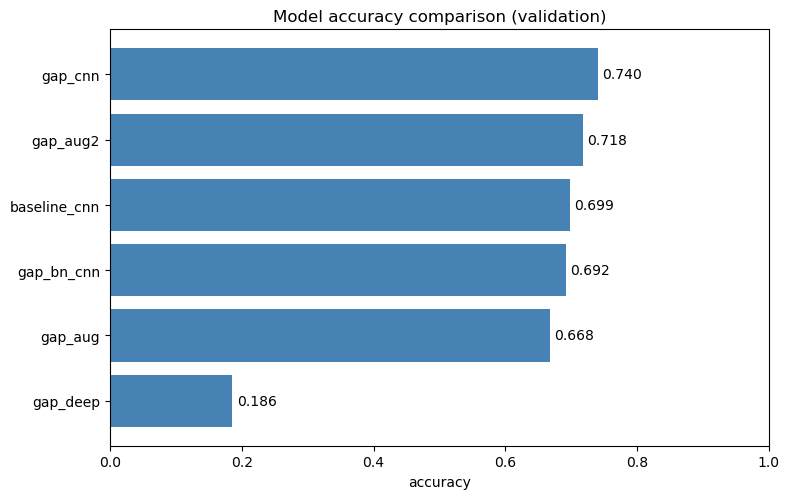

,model,architecture,learning_rate,train_time_min,accuracy,precision,recall,f1,notes
2,gap_deep,"4 conv blocks (8 Conv, +256) -> GlobalAverageP...",0.001,14.6,0.1859,0.0186,0.1000,0.0314,FAILED to train: plain deep CNN collapsed to ~...
0,gap_aug,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,47.3,0.6677,0.6511,0.6433,0.6300,GAP + train augmentation (flip/rotate/shift/zo...
5,gap_bn_cnn,3 conv blocks (Conv-BN-ReLU) -> GlobalAverageP...,0.001,62.6,0.6924,0.7526,0.6448,0.6593,GAP + BatchNorm (val metrics). Test if BN beat...
3,baseline_cnn,3 conv blocks (6 Conv) -> Flatten -> Dropout(0.5),0.001,15.6,0.6988,0.6875,0.6569,0.6677,Baseline (val metrics). Overfits (~13% train-v...
1,gap_aug2,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,54.7,0.7179,0.7065,0.7053,0.6895,Augmentation retry: dropout 0.3 + 60 epochs. T...
4,gap_cnn,3 conv blocks (6 Conv) -> GlobalAveragePooling...,0.001,32.3,0.7403,0.7321,0.7111,0.7136,Flatten -> GAP (val metrics). Less overfit (~8...


In [11]:
from model_metrics import plot_accuracy_comparison

plot_accuracy_comparison()